In [2]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd

In [3]:
from sklearn.datasets import fetch_california_housing
california = fetch_california_housing()

In [4]:
type(california)

sklearn.utils._bunch.Bunch

In [5]:
california.keys()

dict_keys(['data', 'target', 'frame', 'target_names', 'feature_names', 'DESCR'])

In [6]:
print(type(california.data), type(california.target))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [7]:
print(california.data.shape, california.target.shape)

(20640, 8) (20640,)


In [8]:
data = pd.DataFrame(california.data, columns = california.feature_names)
data['Price'] = california.target
data.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [9]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   MedInc      20640 non-null  float64
 1   HouseAge    20640 non-null  float64
 2   AveRooms    20640 non-null  float64
 3   AveBedrms   20640 non-null  float64
 4   Population  20640 non-null  float64
 5   AveOccup    20640 non-null  float64
 6   Latitude    20640 non-null  float64
 7   Longitude   20640 non-null  float64
 8   Price       20640 non-null  float64
dtypes: float64(9)
memory usage: 1.4 MB


In [10]:
data.describe().round(2)

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,Price
count,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00,20640.00
mean,3.87,28.64,5.43,1.10,1425.48,3.07,35.63,-119.57,2.07
std,1.90,12.59,2.47,0.47,1132.46,10.39,2.14,2.00,1.15
min,0.50,1.00,0.85,0.33,3.00,0.69,32.54,-124.35,0.15
25%,2.56,18.00,4.44,1.01,787.00,2.43,33.93,-121.80,1.20
50%,3.53,29.00,5.23,1.05,1166.00,2.82,34.26,-118.49,1.80
75%,4.74,37.00,6.05,1.10,1725.00,3.28,37.71,-118.01,2.65
max,15.00,52.00,141.91,34.07,35682.00,1243.33,41.95,-114.31,5.00


In [11]:
y = data['Price']
X = data.drop('Price', axis=1)

In [12]:
y.shape, X.shape

((20640,), (20640, 8))

In [13]:
from sklearn.linear_model import LinearRegression
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [14]:
print("Coefficients: \n", model.coef_)

Coefficients: 
 [ 4.36693293e-01  9.43577803e-03 -1.07322041e-01  6.45065694e-01
 -3.97638942e-06 -3.78654265e-03 -4.21314378e-01 -4.34513755e-01]


In [15]:
_ = [print(k, v) for k, v in zip(X.columns, model.coef_)]

MedInc 0.4366932931343249
HouseAge 0.009435778033238185
AveRooms -0.10732204139090434
AveBedrms 0.6450656935198135
Population -3.976389421210415e-06
AveOccup -0.0037865426549710075
Latitude -0.42131437752714485
Longitude -0.4345137546747772


In [16]:
print("Intercept: \n", model.intercept_)

Intercept: 
 -36.94192020718437


In [17]:
y_pred = model.predict(X)
print(y_pred[:5])

[4.13164983 3.97660644 3.67657094 3.2415985  2.41358744]


In [18]:
print(y[:5])

0    4.526
1    3.585
2    3.521
3    3.413
4    3.422
Name: Price, dtype: float64


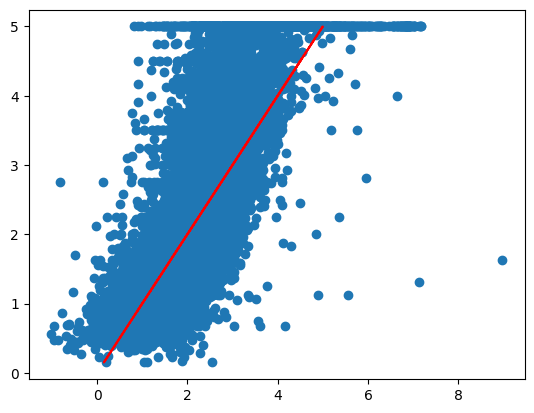

In [19]:
plt.scatter(y_pred, y)
plt.plot(y, y, c='r')

In [20]:
model.score(X, y)

0.606232685199805

In [21]:
from sklearn.preprocessing import PolynomialFeatures
poly = PolynomialFeatures(3).fit_transform(X)

In [22]:
polynomial = LinearRegression()
polynomial.fit(poly, y)
y_pred_poly = polynomial.predict(poly)

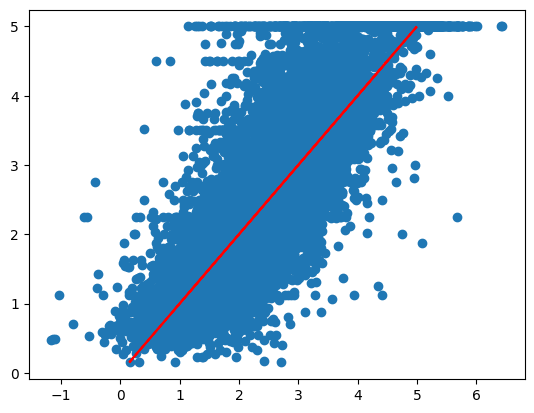

In [23]:
plt.scatter(y_pred_poly, y)
plt.plot(y, y, c='r')

In [24]:
polynomial.score(poly, y)

0.7286583856151427

### Практика

### 1. Информация и изменение аргументов

In [25]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

MSE: 0.5243
RMSE: 0.7241
MAE: 0.5312


In [26]:
for degree in [2, 3, 4, 5]:
    poly = PolynomialFeatures(degree).fit_transform(X)
    model_poly = LinearRegression()
    model_poly.fit(poly, y)
    score = model_poly.score(poly, y)
    print(f"Степень {degree}: R2 = {score:.4f}")

Степень 2: R2 = 0.6833
Степень 3: R2 = 0.7287
Степень 4: R2 = 0.6974
Степень 5: R2 = 0.3663


### 2. Другие модели регрессии

In [27]:
from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.linear_model import Ridge, Lasso, ElasticNet
from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
from sklearn.metrics import r2_score

In [28]:
results = {}

#### Метод ближайших соседей:

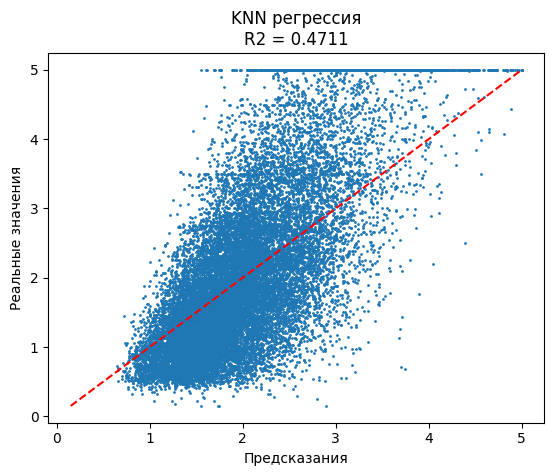

In [29]:
knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X, y)
y_pred_knn = knn.predict(X)

plt.scatter(y_pred_knn, y, s=1)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title(f'KNN регрессия\nR2 = {r2_score(y, y_pred_knn):.4f}')
plt.xlabel('Предсказания')
plt.ylabel('Реальные значения')
plt.show()

results['KNN'] = r2_score(y, y_pred_knn)

#### Многослойный перцептрон:

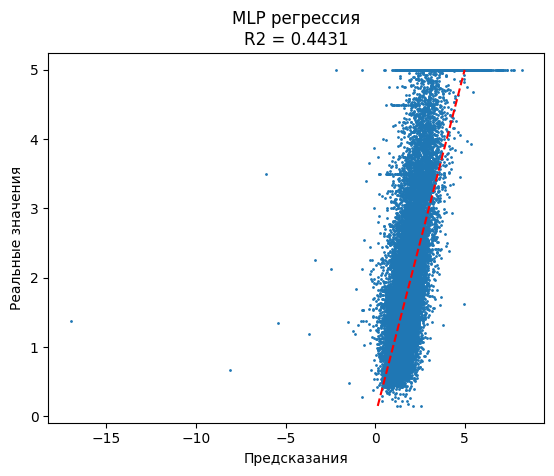

In [30]:
mlp = MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42)
mlp.fit(X, y)
y_pred_mlp = mlp.predict(X)

plt.scatter(y_pred_mlp, y, s=1)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title(f'MLP регрессия\nR2 = {r2_score(y, y_pred_mlp):.4f}')
plt.xlabel('Предсказания')
plt.ylabel('Реальные значения')
plt.show()

results['MLP'] = r2_score(y, y_pred_mlp)

#### Дерево решений:

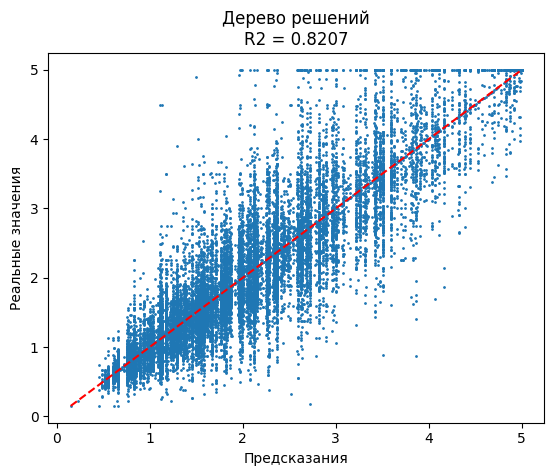

In [31]:
tree = DecisionTreeRegressor(max_depth=10, random_state=42)
tree.fit(X, y)
y_pred_tree = tree.predict(X)

plt.scatter(y_pred_tree, y, s=1)
plt.plot([y.min(), y.max()], [y.min(), y.max()], 'r--')
plt.title(f'Дерево решений\nR2 = {r2_score(y, y_pred_tree):.4f}')
plt.xlabel('Предсказания')
plt.ylabel('Реальные значения')
plt.show()

results['Decision Tree'] = r2_score(y, y_pred_tree)

### 3. Функция обучения

In [33]:
def compare_models(X, y):
    from sklearn.svm import SVR
    from sklearn.neighbors import KNeighborsRegressor
    from sklearn.neural_network import MLPRegressor
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.linear_model import Ridge, Lasso, ElasticNet
    from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
    from sklearn.metrics import r2_score
    
    models = {
        'KNN': KNeighborsRegressor(n_neighbors=5),
        'MLP': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
        'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.01),
        'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Bagging': BaggingRegressor(n_estimators=100, random_state=42)
    }
    
    for name, model in models.items():
        model.fit(X, y)
        y_pred = model.predict(X)
        r2 = r2_score(y, y_pred)
        print(f"{name} : { r2}")

In [34]:
compare_models(X, y)

KNN : 0.471118594496435
MLP : 0.4430909255073877
Decision Tree : 0.8206970165223322
Ridge : 0.6062326586911464
Lasso : 0.6024178576491682
ElasticNet : 0.6044878480909923
Random Forest : 0.973965881606213
Bagging : 0.9739265734357926


### 4. Для другого набора данных

In [37]:
from sklearn.datasets import load_diabetes
diabetes = load_diabetes()

In [47]:
data = pd.DataFrame(diabetes.data, columns=diabetes.feature_names)
data['target'] = diabetes.target
data.head()

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
0,0.038076,0.050680,0.061696,0.021872,-0.044223,-0.034821,-0.043401,-0.002592,0.019907,-0.017646,151.0
1,-0.001882,-0.044642,-0.051474,-0.026328,-0.008449,-0.019163,0.074412,-0.039493,-0.068332,-0.092204,75.0
2,0.085299,0.050680,0.044451,-0.005670,-0.045599,-0.034194,-0.032356,-0.002592,0.002861,-0.025930,141.0
3,-0.089063,-0.044642,-0.011595,-0.036656,0.012191,0.024991,-0.036038,0.034309,0.022688,-0.009362,206.0
4,0.005383,-0.044642,-0.036385,0.021872,0.003935,0.015596,0.008142,-0.002592,-0.031988,-0.046641,135.0


In [48]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 442 entries, 0 to 441
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   age     442 non-null    float64
 1   sex     442 non-null    float64
 2   bmi     442 non-null    float64
 3   bp      442 non-null    float64
 4   s1      442 non-null    float64
 5   s2      442 non-null    float64
 6   s3      442 non-null    float64
 7   s4      442 non-null    float64
 8   s5      442 non-null    float64
 9   s6      442 non-null    float64
 10  target  442 non-null    float64
dtypes: float64(11)
memory usage: 38.1 KB


In [50]:
data.describe().round(2)

,age,sex,bmi,bp,s1,s2,s3,s4,s5,s6,target
count,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00,442.00
mean,-0.00,0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,152.13
std,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,0.05,77.09
min,-0.11,-0.04,-0.09,-0.11,-0.13,-0.12,-0.10,-0.08,-0.13,-0.14,25.00
25%,-0.04,-0.04,-0.03,-0.04,-0.03,-0.03,-0.04,-0.04,-0.03,-0.03,87.00
50%,0.01,-0.04,-0.01,-0.01,-0.00,-0.00,-0.01,-0.00,-0.00,-0.00,140.50
75%,0.04,0.05,0.03,0.04,0.03,0.03,0.03,0.03,0.03,0.03,211.50
max,0.11,0.05,0.17,0.13,0.15,0.20,0.18,0.19,0.13,0.14,346.00


In [51]:
y = data['target']
X = data.drop('target', axis=1)

In [54]:
y.shape, X.shape

((442,), (442, 10))

In [55]:
model = LinearRegression()
model.fit(X, y)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [57]:
model.score(X, y)

0.5177484222203498

In [58]:
y_pred = model.predict(X)

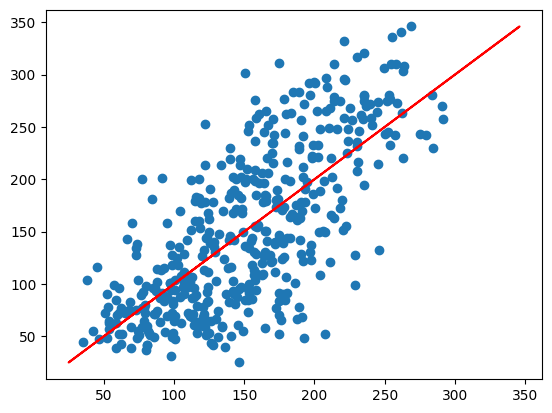

In [59]:
plt.scatter(y_pred, y)
plt.plot(y, y, c='r')

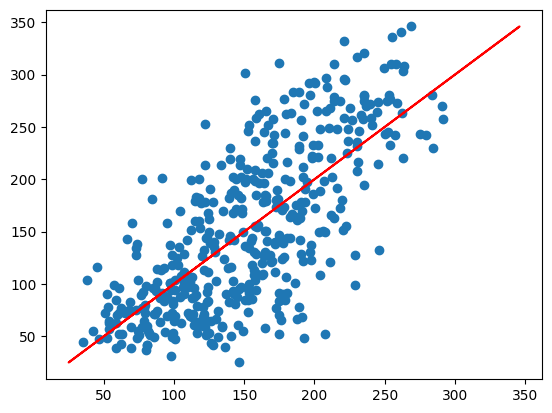

Для полинома степени 1 коэфф R2 равен = 0.5177484222203499


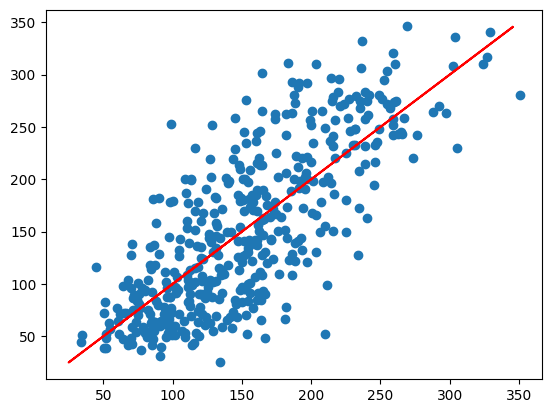

Для полинома степени 2 коэфф R2 равен = 0.5924402750960331


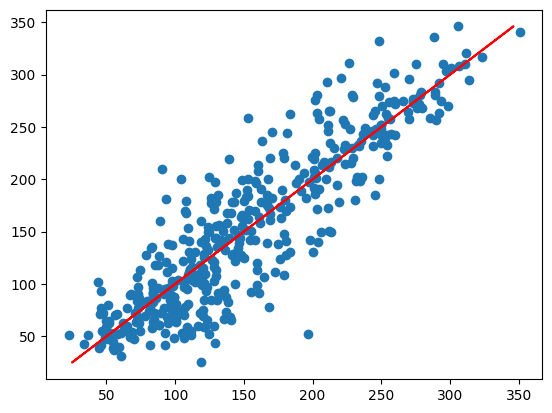

Для полинома степени 3 коэфф R2 равен = 0.7980671723794027


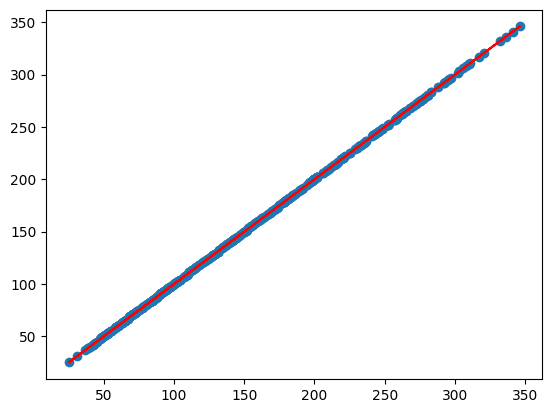

Для полинома степени 4 коэфф R2 равен = 1.0


In [71]:
for num_poly in range(1, 5):
    poly = PolynomialFeatures(num_poly).fit_transform(X)
    polynom = LinearRegression()
    polynom.fit(poly, y)
    y_pred_poly = polynom.predict(poly)

    plt.scatter(y_pred_poly, y)
    plt.plot(y, y, c='r')
    plt.show()
    
    print(f"Для полинома степени {num_poly} коэфф R2 равен = {polynom.score(poly, y)}")

In [72]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)

print(f"MSE: {mse:.4f}")
print(f"RMSE: {rmse:.4f}")
print(f"MAE: {mae:.4f}")

MSE: 2859.6963
RMSE: 53.4761
MAE: 43.2775


In [75]:
def compare_models(X, y):
    from sklearn.svm import SVR
    from sklearn.neighbors import KNeighborsRegressor
    from sklearn.neural_network import MLPRegressor
    from sklearn.tree import DecisionTreeRegressor
    from sklearn.linear_model import Ridge, Lasso, ElasticNet
    from sklearn.ensemble import RandomForestRegressor, BaggingRegressor
    from sklearn.metrics import r2_score
    
    models = {
        'KNN': KNeighborsRegressor(n_neighbors=5),
        'MLP': MLPRegressor(hidden_layer_sizes=(100, 50), max_iter=500, random_state=42),
        'Decision Tree': DecisionTreeRegressor(max_depth=10, random_state=42),
        'Ridge': Ridge(alpha=1.0),
        'Lasso': Lasso(alpha=0.01),
        'ElasticNet': ElasticNet(alpha=0.01, l1_ratio=0.5),
        'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
        'Bagging': BaggingRegressor(n_estimators=100, random_state=42)
    }
    
    for name, model in models.items():
        model.fit(X, y)
        y_pred = model.predict(X)
        r2 = r2_score(y, y_pred)
        print(f"{name}: {round(r2, 4)}")

compare_models(X, y)

KNN: 0.605


/opt/homebrew/Cellar/jupyterlab/4.4.10/libexec/lib/python3.14/site-packages/sklearn/neural_network/_multilayer_perceptron.py:781: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (500) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP: 0.5054
Decision Tree: 0.9645
Ridge: 0.4512
Lasso: 0.5162
ElasticNet: 0.3791
Random Forest: 0.9196
Bagging: 0.9203
